# Pancake layer 48: variance-aware PCA → UMAP-3

対象は `N3_mm3`, `N4_mm3`, `N4_mm4`, `N5_mm3`, `N5_mm4`, `N5_mm5` の各100 trial、合計600 trial。入力は `results/pancake_2026-08-27_overnight/derived/top_layer/` のlayer 48派生HDF5/JSON。

このnotebookは計算、可視化、品質指標、manifest、成果物整合性を記録する。

## 実行設定

- 各trialから最大32時点を両端込みの等間隔で抽出する。
- PCAはhidden size 5120、non-whitened randomized SVD、`iterated_power=4`、最大512成分。
- `n90` は累積説明分散が0.90へ初めて到達する最小成分数。
- 条件別PCA/UMAPは各条件の100 trialから得た3,200時点をfit/referenceとする。
- 共通PCA/UMAPは固定seed `20260828` により各条件25 trialを無作為・非復元抽出し、150 trial・4,800時点をfit/referenceとする。残り450 trialをPCA held-out再構成評価に使う。
- UMAP-3は `n_neighbors=30`, `min_dist=0.15`, `metric='euclidean'`。
- UMAP seed stabilityはseed `20260828`, `20260829`, `20260830` 間の、固定点対における埋め込み距離Spearman相関の平均。
- continuityはreference空間と埋め込み空間を交換したtrustworthinessとして算出する。

In [2]:
from __future__ import annotations

import csv
import json
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import Markdown, display

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'AGENTS.md').is_file() and (candidate / 'results').is_dir():
            return candidate
    raise FileNotFoundError('repository rootが見つかりません')

REPO_ROOT = find_repo_root(Path.cwd())
ANALYSIS_DIR = REPO_ROOT / 'results/pancake_2026-08-27_overnight'
OUTPUT_ROOT = ANALYSIS_DIR / 'variance_aware_umap3'
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIGURE_DIR = ANALYSIS_DIR / 'figures/variance_aware_umap3'
SCRIPT = ANALYSIS_DIR / 'scripts/variance_aware_umap3.py'
print(REPO_ROOT)
print(SCRIPT)

/home/shona/Modeling_of_LLMs_LPT
/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-27_overnight/scripts/variance_aware_umap3.py


In [3]:
environment = os.environ.copy()
environment['MPLCONFIGDIR'] = '/tmp/matplotlib-pancake-umap3'
environment['NUMBA_CACHE_DIR'] = '/tmp/numba-pancake-umap3'
completed = subprocess.run(
    [sys.executable, '-u', str(SCRIPT), '--repo-root', str(REPO_ROOT)],
    cwd=REPO_ROOT,
    env=environment,
    text=True,
    capture_output=True,
    check=True,
)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr, file=sys.stderr)

2026-08-29 22:05:57,940 INFO analysis version=2026-08-28-v1
2026-08-29 22:05:58,004 INFO [INPUT] N3_mm3 trials=100
2026-08-29 22:05:58,069 INFO [INPUT] N4_mm3 trials=100
2026-08-29 22:05:58,132 INFO [INPUT] N4_mm4 trials=100
2026-08-29 22:05:58,204 INFO [INPUT] N5_mm3 trials=100
2026-08-29 22:05:58,288 INFO [INPUT] N5_mm4 trials=100
2026-08-29 22:05:58,376 INFO [INPUT] N5_mm5 trials=100
2026-08-29 22:05:58,376 INFO [RESUME] N3_mm3 completed cellを再利用
2026-08-29 22:05:58,377 INFO [RESUME] N4_mm3 completed cellを再利用
2026-08-29 22:05:58,378 INFO [RESUME] N4_mm4 completed cellを再利用
2026-08-29 22:05:58,379 INFO [RESUME] N5_mm3 completed cellを再利用
2026-08-29 22:05:58,381 INFO [RESUME] N5_mm4 completed cellを再利用
2026-08-29 22:05:58,382 INFO [RESUME] N5_mm5 completed cellを再利用
2026-08-29 22:05:58,403 INFO [RESUME] Phase B completed common spaceを再利用
2026-08-29 22:05:58,558 INFO [COMPLETE] 6 conditions, shared space, 7 figures, tables and manifests verified



## Phase A: 条件別PCA・UMAP-3

条件ごとにPCA-n90をfitし、そのPCA scoreをUMAP-3へ入力する。品質指標はUMAP fit/referenceの3,200時点で算出する。

In [4]:
def read_csv(path: Path) -> list[dict[str, str]]:
    with path.open(encoding='utf-8', newline='') as handle:
        return list(csv.DictReader(handle))

def markdown_table(headers: list[str], rows: list[list[str]]) -> str:
    lines = [
        '| ' + ' | '.join(headers) + ' |',
        '| ' + ' | '.join('---' for _ in headers) + ' |',
    ]
    lines.extend('| ' + ' | '.join(row) + ' |' for row in rows)
    return '\n'.join(lines)

pca_rows = read_csv(TABLE_DIR / 'condition_pca_summary.csv')
display(Markdown(markdown_table(
    ['cell', 'fit shape', 'PC1–3', 'PC1–50', 'n90', 'at n90', 'fit sec', '90% reached'],
    [[
        row['cell'],
        f"{row['fit_sample_rows']} × {row['fit_sample_columns']}",
        f"{float(row['pc1_3_cumulative_explained_ratio']):.4f}",
        f"{float(row['pc1_50_cumulative_explained_ratio']):.4f}",
        row['n90'],
        f"{float(row['n90_cumulative_explained_ratio']):.4f}",
        f"{float(row['pca_fit_seconds']):.2f}",
        row['reached_90_percent'],
    ] for row in pca_rows],
)))

| cell | fit shape | PC1–3 | PC1–50 | n90 | at n90 | fit sec | 90% reached |
| --- | --- | --- | --- | --- | --- | --- | --- |
| N3_mm3 | 3200 × 5120 | 0.3804 | 0.7544 | 258 | 0.9002 | 2.51 | True |
| N4_mm3 | 3200 × 5120 | 0.3818 | 0.7608 | 252 | 0.9000 | 2.95 | True |
| N4_mm4 | 3200 × 5120 | 0.3916 | 0.7687 | 238 | 0.9001 | 2.37 | True |
| N5_mm3 | 3200 × 5120 | 0.3830 | 0.7582 | 263 | 0.9001 | 3.34 | True |
| N5_mm4 | 3200 × 5120 | 0.3806 | 0.7582 | 266 | 0.9001 | 2.88 | True |
| N5_mm5 | 3200 × 5120 | 0.3860 | 0.7596 | 262 | 0.9001 | 2.62 | True |

In [5]:
umap_rows = read_csv(TABLE_DIR / 'condition_umap_metrics.csv')
display(Markdown(markdown_table(
    ['cell', 'PCA n', 'trust@15', 'continuity@15', 'trust@50', 'continuity@50', 'distance ρ', 'seed stability', 'fit sec'],
    [[
        row['cell'], row['pca_input_components'],
        f"{float(row['trustworthiness_at_15']):.3f}",
        f"{float(row['continuity_at_15']):.3f}",
        f"{float(row['trustworthiness_at_50']):.3f}",
        f"{float(row['continuity_at_50']):.3f}",
        f"{float(row['distance_spearman_rho']):.3f}",
        f"{float(row['umap_seed_stability']):.3f}",
        f"{float(row['umap_fit_seconds']):.2f}",
    ] for row in umap_rows],
)))

| cell | PCA n | trust@15 | continuity@15 | trust@50 | continuity@50 | distance ρ | seed stability | fit sec |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| N3_mm3 | 258 | 0.987 | 0.987 | 0.975 | 0.971 | 0.656 | 0.964 | 11.63 |
| N4_mm3 | 252 | 0.989 | 0.989 | 0.976 | 0.974 | 0.601 | 0.975 | 6.30 |
| N4_mm4 | 238 | 0.989 | 0.990 | 0.977 | 0.972 | 0.600 | 0.968 | 6.20 |
| N5_mm3 | 263 | 0.987 | 0.990 | 0.974 | 0.973 | 0.563 | 0.972 | 6.39 |
| N5_mm4 | 266 | 0.986 | 0.987 | 0.973 | 0.969 | 0.543 | 0.954 | 6.42 |
| N5_mm5 | 262 | 0.985 | 0.989 | 0.970 | 0.973 | 0.527 | 0.943 | 6.45 |

## 代表seed選定と凡例

可視化前に次の順で選ぶ: 最短生成、生成長中央値付近、最長生成、repeated-state比率最低、repeated-state比率最高。各項目では既選択trialを除き、項目固有rankingの先頭を選ぶ。tie-breakはsample seed昇順。success/non-successが共存し初期選択が一方だけの場合は、同じ選定項目内でmissing outcomeの未選択trialへ決定的に置換する。

代表reasoning線は選定項目の固定色、successは実線、non-successは破線。背景は100 trialの32時点軌道を薄い灰色で表示する。earlier closed finalは紫点線、last closed finalは暗赤線。startは白丸、goalは緑星、repeated stateは橙X。

In [6]:
representatives = read_csv(TABLE_DIR / 'condition_representative_seeds.csv')
display(Markdown(markdown_table(
    ['cell', 'seed', 'tokens', 'repeat ratio', 'outcome', 'selection item', 'closed finals', 'last final'],
    [[
        row['cell'], row['sample_seed'], row['generated_token_count'],
        f"{float(row['repeated_state_ratio']):.3f}", row['outcome'],
        row['selection_item'], row['final_block_count'], row['last_closed_final_present'],
    ] for row in representatives],
)))

| cell | seed | tokens | repeat ratio | outcome | selection item | closed finals | last final |
| --- | --- | --- | --- | --- | --- | --- | --- |
| N3_mm3 | 13 | 535 | 0.667 | success_final | shortest_generation | 1 | True |
| N3_mm3 | 79 | 1067 | 0.821 | success_final | median_generation | 1 | True |
| N3_mm3 | 1 | 2708 | 0.937 | success_final | longest_generation | 6 | True |
| N3_mm3 | 8 | 695 | 0.500 | success_final | lowest_repeated_state_ratio | 1 | True |
| N3_mm3 | 29 | 2149 | 0.912 | success_final | highest_repeated_state_ratio | 3 | True |
| N4_mm3 | 137 | 746 | 0.286 | success_final | shortest_generation | 1 | True |
| N4_mm3 | 155 | 2098 | 0.577 | success_final | median_generation | 1 | True |
| N4_mm3 | 198 | 8192 | 0.880 | length_censored | longest_generation | 1 | True |
| N4_mm3 | 139 | 4816 | 0.000 | success_final | lowest_repeated_state_ratio | 1 | True |
| N4_mm3 | 188 | 6345 | 0.908 | success_final | highest_repeated_state_ratio | 1 | True |
| N4_mm4 | 280 | 895 | 0.333 | success_final | shortest_generation | 1 | True |
| N4_mm4 | 242 | 2298 | 0.488 | success_final | median_generation | 1 | True |
| N4_mm4 | 250 | 8036 | 0.902 | search_success_final_fail | longest_generation | 2 | True |
| N4_mm4 | 292 | 920 | 0.167 | success_final | lowest_repeated_state_ratio | 1 | True |
| N4_mm4 | 255 | 8018 | 0.907 | search_success_final_fail | highest_repeated_state_ratio | 1 | True |
| N5_mm3 | 349 | 1022 | 0.111 | success_final | shortest_generation | 1 | True |
| N5_mm3 | 304 | 3465 | 0.559 | success_final | median_generation | 2 | True |
| N5_mm3 | 320 | 8192 | 0.500 | length_censored | longest_generation | 0 | False |
| N5_mm3 | 327 | 2208 | 0.000 | success_final | lowest_repeated_state_ratio | 1 | True |
| N5_mm3 | 302 | 2157 | 0.850 | success_final | highest_repeated_state_ratio | 1 | True |
| N5_mm4 | 414 | 1562 | 0.120 | success_final | shortest_generation | 1 | True |
| N5_mm4 | 437 | 6641 | 0.259 | success_final | median_generation | 1 | True |
| N5_mm4 | 404 | 8192 | 0.553 | length_censored | longest_generation | 1 | True |
| N5_mm4 | 494 | 2308 | 0.000 | success_final | lowest_repeated_state_ratio | 1 | True |
| N5_mm4 | 460 | 2311 | 0.654 | success_final | highest_repeated_state_ratio | 1 | True |
| N5_mm5 | 558 | 1709 | 0.192 | success_final | shortest_generation | 1 | True |
| N5_mm5 | 536 | 5437 | 0.597 | search_fail | median_generation | 1 | True |
| N5_mm5 | 509 | 8192 | 0.555 | length_censored | longest_generation | 0 | False |
| N5_mm5 | 501 | 4863 | 0.000 | search_fail | lowest_repeated_state_ratio | 1 | True |
| N5_mm5 | 508 | 5877 | 0.661 | success_final | highest_repeated_state_ratio | 2 | True |

In [7]:
for index, cell in enumerate(['N3_mm3', 'N4_mm3', 'N4_mm4', 'N5_mm3', 'N5_mm4', 'N5_mm5'], start=1):
    relative = f'../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/{index:02d}_{cell}_umap3.png'
    display(Markdown(f'### {cell}\n\n![{cell}]({relative})'))

### N3_mm3

![N3_mm3](../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/01_N3_mm3_umap3.png)

### N4_mm3

![N4_mm3](../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/02_N4_mm3_umap3.png)

### N4_mm4

![N4_mm4](../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/03_N4_mm4_umap3.png)

### N5_mm3

![N5_mm3](../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/04_N5_mm3_umap3.png)

### N5_mm4

![N5_mm4](../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/05_N5_mm4_umap3.png)

### N5_mm5

![N5_mm5](../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/06_N5_mm5_umap3.png)

## Phase B: 全条件共通PCA・共通UMAP-3

共通PCA/UMAPのfit trialと450 held-out trialは `common_pca_sampling_manifest.json` に分離して保存する。UMAP referenceは共通PCA fitと同じ4,800時点で、6条件各25 trial。Phase Aの代表30 trialを同じ共通PCA基底と同じ共通UMAPへtransformする。

In [8]:
common_pca = json.loads((TABLE_DIR / 'common_pca_summary.json').read_text(encoding='utf-8'))
common_umap = json.loads((TABLE_DIR / 'common_umap_metrics.json').read_text(encoding='utf-8'))
common_rows = [
    ['fit shape', f"{common_pca['fit_sample_rows']} × {common_pca['fit_sample_columns']}"],
    ['PC1–3', f"{common_pca['pc1_3_cumulative_explained_ratio']:.4f}"],
    ['PC1–50', f"{common_pca['pc1_50_cumulative_explained_ratio']:.4f}"],
    ['n90', str(common_pca['n90'])],
    ['at n90', f"{common_pca['n90_cumulative_explained_ratio']:.4f}"],
    ['held-out trials', str(common_pca['heldout_trial_count'])],
    ['held-out pooled reconstruction ratio', f"{common_pca['heldout_reconstruction_explained_ratio_pooled']:.4f}"],
    ['trustworthiness@15', f"{common_umap['trustworthiness_at_15']:.3f}"],
    ['continuity@15', f"{common_umap['continuity_at_15']:.3f}"],
    ['trustworthiness@50', f"{common_umap['trustworthiness_at_50']:.3f}"],
    ['continuity@50', f"{common_umap['continuity_at_50']:.3f}"],
    ['distance Spearman ρ', f"{common_umap['distance_spearman_rho']:.3f}"],
    ['UMAP seed stability', f"{common_umap['umap_seed_stability']:.3f}"],
    ['UMAP fit sec', f"{common_umap['umap_fit_seconds']:.2f}"],
    ['representative transform sec', f"{common_umap['representative_transform_seconds']:.2f}"],
]
display(Markdown(markdown_table(['item', 'value'], common_rows)))

| item | value |
| --- | --- |
| fit shape | 4800 × 5120 |
| PC1–3 | 0.3809 |
| PC1–50 | 0.7534 |
| n90 | 295 |
| at n90 | 0.9001 |
| held-out trials | 450 |
| held-out pooled reconstruction ratio | 0.8744 |
| trustworthiness@15 | 0.990 |
| continuity@15 | 0.991 |
| trustworthiness@50 | 0.979 |
| continuity@50 | 0.981 |
| distance Spearman ρ | 0.560 |
| UMAP seed stability | 0.973 |
| UMAP fit sec | 17.56 |
| representative transform sec | 25.54 |

## 共通座標の層化図

4 facetは同じ共通PCA基底、共通UMAP、座標軸、視点を使う。左上は6条件、右上はN、左下はmin_moves、右下はoutcome。successは実線、non-successは破線。

In [9]:
relative = '../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/07_common_umap3_stratified.png'
display(Markdown(f'![shared UMAP-3 stratification]({relative})'))

![shared UMAP-3 stratification](../../results/pancake_2026-08-27_overnight/figures/variance_aware_umap3/07_common_umap3_stratified.png)

## 保存物と検証

難易度補助値は1 trial 1行で、N、min_moves、`log2(N!)`、`min_moves × log2(N-1)`、条件success rate、generated token count、repeated-state比率を保存する。警告は `execution_warnings.json`、file hashは `artifact_manifest.json` に保存する。

In [10]:
manifest = json.loads((OUTPUT_ROOT / 'artifact_manifest.json').read_text(encoding='utf-8'))
warning_rows = json.loads((OUTPUT_ROOT / 'execution_warnings.json').read_text(encoding='utf-8'))
representative_counts = {}
for row in representatives:
    representative_counts[row['cell']] = representative_counts.get(row['cell'], 0) + 1
assert manifest['trial_count'] == 600
assert manifest['condition_count'] == 6
assert manifest['condition_figure_count'] == 6
assert manifest['common_figure_count'] == 1
assert set(representative_counts.values()) == {5}
assert all(int(row['pca_input_components']) == int(pca['n90']) for row, pca in zip(umap_rows, pca_rows))
assert int(common_umap['pca_input_components']) == int(common_pca['n90'])
assert all((FIGURE_DIR / f'{index:02d}_{cell}_umap3.png').is_file() for index, cell in enumerate(['N3_mm3', 'N4_mm3', 'N4_mm4', 'N5_mm3', 'N5_mm4', 'N5_mm5'], start=1))
assert (FIGURE_DIR / '07_common_umap3_stratified.png').is_file()
print(f"Verified: {manifest['trial_count']} trials, 6 cells, 30 representatives, 7 figures")
print(f"Recorded warnings: {len(warning_rows)}")

Verified: 600 trials, 6 cells, 30 representatives, 7 figures
Recorded warnings: 0


In [11]:
from collections import defaultdict
from itertools import product

import h5py
import joblib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image as IPyImage
from matplotlib.lines import Line2D

# 入力は既存の08/27 overnight解析。
SOURCE_ROOT = REPO_ROOT / "results/pancake_2026-08-27_overnight"
SOURCE_DERIVED_DIR = SOURCE_ROOT / "derived/top_layer"
SOURCE_MODEL_DIR = SOURCE_ROOT / "variance_aware_umap3/models"

# 新しい解析結果は08/29の非overnightディレクトリへ分離する。
RUN_ROOT = REPO_ROOT / "results/pancake_2026-08-29"
OUTPUT_ROOT = RUN_ROOT / "matched_outcome_pre_final_post"
FIGURE_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
COORDINATE_DIR = OUTPUT_ROOT / "coordinates"

for directory in [FIGURE_DIR, TABLE_DIR, COORDINATE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault(
    "MPLCONFIGDIR",
    "/tmp/matplotlib-pancake-pre-final-post",
)
os.environ.setdefault(
    "NUMBA_CACHE_DIR",
    "/tmp/numba-pancake-pre-final-post",
)

TARGET_CELL = "N5_mm5"
MATCHED_SET_COUNT = 2

OUTCOME_ORDER = [
    "success_final",
    "search_success_final_fail",
    "search_fail",
    "length_censored",
]

OUTCOME_LABELS = {
    "success_final": "success",
    "search_success_final_fail": "search success / final fail",
    "search_fail": "search fail",
    "length_censored": "length censored",
}

OUTCOME_COLORS = {
    "success_final": "#15803D",
    "search_success_final_fail": "#D97706",
    "search_fail": "#DC2626",
    "length_censored": "#64748B",
}


def repeated_state_ratio(trial: dict) -> float:
    moves = [
        move
        for move in trial["events"]["moves"]
        if move.get("legal") is not False
    ]
    if not moves:
        return float("nan")
    return float(np.mean([
        bool(move.get("repeated_state"))
        for move in moves
    ]))


metadata_path = SOURCE_DERIVED_DIR / f"{TARGET_CELL}.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
all_trials = metadata["trials"]

trials_by_state = defaultdict(list)
for trial in all_trials:
    trials_by_state[tuple(trial["initial_state"])].append(trial)

candidate_sets = []

for initial_state, state_trials in trials_by_state.items():
    trials_by_outcome = {
        outcome: [
            trial
            for trial in state_trials
            if trial["outcome"] == outcome
        ]
        for outcome in OUTCOME_ORDER
    }

    # 4 outcomeすべてが同一initial stateに存在する場合だけ使う。
    if not all(trials_by_outcome[outcome] for outcome in OUTCOME_ORDER):
        continue

    best = None

    for combination in product(*[
        trials_by_outcome[outcome]
        for outcome in OUTCOME_ORDER
    ]):
        success = combination[0]
        success_length = int(success["generated_token_count"])

        log_length_differences = [
            abs(np.log(
                int(trial["generated_token_count"]) / success_length
            ))
            for trial in combination[1:]
        ]

        score = (
            float(sum(log_length_differences)),
            float(max(log_length_differences)),
            tuple(int(trial["sample_seed"]) for trial in combination),
        )

        if best is None or score < best["score"]:
            best = {
                "initial_state": initial_state,
                "score": score,
                "members": {
                    outcome: trial
                    for outcome, trial in zip(
                        OUTCOME_ORDER,
                        combination,
                    )
                },
            }

    candidate_sets.append(best)

candidate_sets.sort(key=lambda item: item["score"])
matched_sets = candidate_sets[:MATCHED_SET_COUNT]

selection_rows = []

for set_index, matched_set in enumerate(matched_sets, start=1):
    success_length = int(
        matched_set["members"]["success_final"]["generated_token_count"]
    )

    for outcome in OUTCOME_ORDER:
        trial = matched_set["members"][outcome]
        token_count = int(trial["generated_token_count"])

        selection_rows.append({
            "matched_set": set_index,
            "cell": TARGET_CELL,
            "initial_state": json.dumps(
                list(matched_set["initial_state"])
            ),
            "outcome": outcome,
            "sample_seed": int(trial["sample_seed"]),
            "generated_token_count": token_count,
            "length_ratio_to_success": (
                max(token_count, success_length)
                / min(token_count, success_length)
            ),
            "repeated_state_ratio": repeated_state_ratio(trial),
        })

selection_path = TABLE_DIR / "matched_seed_selection.csv"

with selection_path.open(
    "w",
    encoding="utf-8",
    newline="",
) as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=list(selection_rows[0]),
    )
    writer.writeheader()
    writer.writerows(selection_rows)

display(Markdown(markdown_table(
    [
        "set",
        "initial state",
        "outcome",
        "seed",
        "tokens",
        "length ratio",
        "repeat ratio",
    ],
    [
        [
            str(row["matched_set"]),
            row["initial_state"],
            row["outcome"],
            str(row["sample_seed"]),
            str(row["generated_token_count"]),
            f"{row['length_ratio_to_success']:.3f}",
            f"{row['repeated_state_ratio']:.3f}",
        ]
        for row in selection_rows
    ],
)))

print(selection_path)

| set | initial state | outcome | seed | tokens | length ratio | repeat ratio |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | [2, 4, 3, 5, 1] | success_final | 528 | 7399 | 1.000 | 0.518 |
| 1 | [2, 4, 3, 5, 1] | search_success_final_fail | 524 | 7750 | 1.047 | 0.456 |
| 1 | [2, 4, 3, 5, 1] | search_fail | 522 | 7538 | 1.019 | 0.381 |
| 1 | [2, 4, 3, 5, 1] | length_censored | 521 | 8192 | 1.107 | 0.458 |
| 2 | [1, 5, 3, 4, 2] | success_final | 502 | 7570 | 1.000 | 0.423 |
| 2 | [1, 5, 3, 4, 2] | search_success_final_fail | 506 | 7309 | 1.036 | 0.583 |
| 2 | [1, 5, 3, 4, 2] | search_fail | 510 | 6957 | 1.088 | 0.466 |
| 2 | [1, 5, 3, 4, 2] | length_censored | 509 | 8192 | 1.082 | 0.555 |

/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/tables/matched_seed_selection.csv


In [12]:
selected_trials = {
    int(trial["sample_seed"]): trial
    for matched_set in matched_sets
    for trial in matched_set["members"].values()
}

coordinate_path = (
    COORDINATE_DIR
    / f"{TARGET_CELL}_matched_common_pca_umap.npz"
)

expected_coordinate_keys = {
    key
    for seed in selected_trials
    for key in [f"pca_seed_{seed}", f"umap_seed_{seed}"]
}

pca_paths = {}
umap_paths = {}
reuse_coordinates = False

if coordinate_path.is_file():
    with np.load(coordinate_path) as cached:
        if expected_coordinate_keys.issubset(cached.files):
            pca_paths = {
                seed: cached[f"pca_seed_{seed}"].copy()
                for seed in selected_trials
            }
            umap_paths = {
                seed: cached[f"umap_seed_{seed}"].copy()
                for seed in selected_trials
            }
            reuse_coordinates = True

if reuse_coordinates:
    print(f"再利用: {coordinate_path}")
else:
    with np.load(SOURCE_MODEL_DIR / "pca_common.npz") as pca_data:
        pca_mean = pca_data["mean"].astype(np.float32)
        n90 = int(pca_data["n90"])
        pca_components = (
            pca_data["components"][:n90]
            .astype(np.float32)
        )

    reducer = joblib.load(
        SOURCE_MODEL_DIR / "umap_common.joblib"
    )

    h5_path = SOURCE_DERIVED_DIR / f"{TARGET_CELL}.h5"

    with h5py.File(h5_path, "r") as h5:
        for seed, trial in sorted(selected_trials.items()):
            dataset = h5["trials"][trial["trial_id"]]["hidden"]
            row_count = int(dataset.shape[0])

            scores = np.empty(
                (row_count, n90),
                dtype=np.float32,
            )

            for start in range(0, row_count, 4096):
                end = min(start + 4096, row_count)
                hidden = dataset[start:end].astype(np.float32)
                scores[start:end] = (
                    hidden - pca_mean
                ) @ pca_components.T

            coordinates = np.empty(
                (row_count, 3),
                dtype=np.float32,
            )

            for start in range(0, row_count, 4096):
                end = min(start + 4096, row_count)
                coordinates[start:end] = reducer.transform(
                    scores[start:end]
                )

            pca_paths[seed] = scores
            umap_paths[seed] = coordinates

            print(
                f"seed={seed}: "
                f"{row_count} tokensを投影"
            )

    coordinate_payload = {}

    for seed in selected_trials:
        coordinate_payload[f"pca_seed_{seed}"] = pca_paths[seed]
        coordinate_payload[f"umap_seed_{seed}"] = umap_paths[seed]

    np.savez_compressed(
        coordinate_path,
        **coordinate_payload,
    )

    print(f"保存: {coordinate_path}")

再利用: /home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/coordinates/N5_mm5_matched_common_pca_umap.npz


In [13]:
BOUNDARY_WINDOW = 128


def final_phase_bounds(
    trial: dict,
    trajectory_length: int,
) -> dict:
    """最後のfinalについてpre/final/post境界を返す。"""
    intervals = trial["events"].get("final_intervals", [])

    if intervals:
        start, end = map(int, intervals[-1])
        start = max(0, min(start, trajectory_length - 1))
        end = max(start, min(end, trajectory_length - 1))

        return {
            "status": "closed",
            "start": start,
            "end": end,
        }

    open_start = trial["events"].get("open_final_start")

    if open_start is not None:
        start = max(
            0,
            min(int(open_start), trajectory_length - 1),
        )

        return {
            "status": "open",
            "start": start,
            "end": trajectory_length - 1,
        }

    return {
        "status": "none",
        "start": None,
        "end": None,
    }


def temporal_bin_means(
    values: np.ndarray,
    maximum_bins: int,
) -> np.ndarray:
    """系列を等token区間へ分け、区間重心を返す。"""
    if len(values) == 0:
        return np.empty(
            (0, values.shape[1]),
            dtype=np.float32,
        )

    bin_count = min(maximum_bins, len(values))
    edges = np.linspace(
        0,
        len(values),
        bin_count + 1,
        dtype=int,
    )

    return np.stack([
        values[edges[index]:edges[index + 1]].mean(axis=0)
        for index in range(bin_count)
    ])


def set_shared_3d_limits(
    ax,
    center: np.ndarray,
    radius: float,
) -> None:
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)


phase_rows = []

for set_index, matched_set in enumerate(matched_sets, start=1):
    for outcome in OUTCOME_ORDER:
        trial = matched_set["members"][outcome]
        seed = int(trial["sample_seed"])
        scores = pca_paths[seed]

        bounds = final_phase_bounds(trial, len(scores))
        start = bounds["start"]
        end = bounds["end"]

        if start is None:
            pre_count = len(scores)
            final_count = 0
            post_count = 0
            pre_to_final = float("nan")
            final_to_post = float("nan")
        else:
            pre = scores[max(0, start - BOUNDARY_WINDOW):start]
            final = scores[start:end + 1]
            post = scores[
                end + 1:min(len(scores), end + 1 + BOUNDARY_WINDOW)
            ]

            pre_count = start
            final_count = end - start + 1
            post_count = len(scores) - end - 1

            pre_to_final = (
                float(np.linalg.norm(
                    pre.mean(axis=0) - final.mean(axis=0)
                ))
                if len(pre) and len(final)
                else float("nan")
            )

            final_to_post = (
                float(np.linalg.norm(
                    final.mean(axis=0) - post.mean(axis=0)
                ))
                if len(final) and len(post)
                else float("nan")
            )

        phase_rows.append({
            "matched_set": set_index,
            "initial_state": json.dumps(
                list(matched_set["initial_state"])
            ),
            "outcome": outcome,
            "sample_seed": seed,
            "final_status": bounds["status"],
            "final_start": start,
            "final_end": end,
            "pre_final_token_count": pre_count,
            "final_token_count": final_count,
            "post_final_token_count": post_count,
            "pre128_to_final_centroid_distance_pca": pre_to_final,
            "final_to_post128_centroid_distance_pca": final_to_post,
        })

phase_summary_path = (
    TABLE_DIR / "matched_pre_final_post_summary.csv"
)

with phase_summary_path.open(
    "w",
    encoding="utf-8",
    newline="",
) as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=list(phase_rows[0]),
    )
    writer.writeheader()
    writer.writerows(phase_rows)

display(Markdown(markdown_table(
    [
        "set",
        "outcome",
        "seed",
        "status",
        "final start",
        "final end",
        "pre tokens",
        "final tokens",
        "post tokens",
    ],
    [
        [
            str(row["matched_set"]),
            row["outcome"],
            str(row["sample_seed"]),
            row["final_status"],
            str(row["final_start"]),
            str(row["final_end"]),
            str(row["pre_final_token_count"]),
            str(row["final_token_count"]),
            str(row["post_final_token_count"]),
        ]
        for row in phase_rows
    ],
)))

print(phase_summary_path)

| set | outcome | seed | status | final start | final end | pre tokens | final tokens | post tokens |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | success_final | 528 | closed | 7376 | 7396 | 7376 | 21 | 2 |
| 1 | search_success_final_fail | 524 | closed | 7533 | 7553 | 7533 | 21 | 196 |
| 1 | search_fail | 522 | closed | 7519 | 7535 | 7519 | 17 | 2 |
| 1 | length_censored | 521 | closed | 7594 | 7606 | 7594 | 13 | 585 |
| 2 | success_final | 502 | closed | 7547 | 7567 | 7547 | 21 | 2 |
| 2 | search_success_final_fail | 506 | closed | 7286 | 7306 | 7286 | 21 | 2 |
| 2 | search_fail | 510 | closed | 6934 | 6954 | 6934 | 21 | 2 |
| 2 | length_censored | 509 | none | None | None | 8192 | 0 | 0 |

/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/tables/matched_pre_final_post_summary.csv


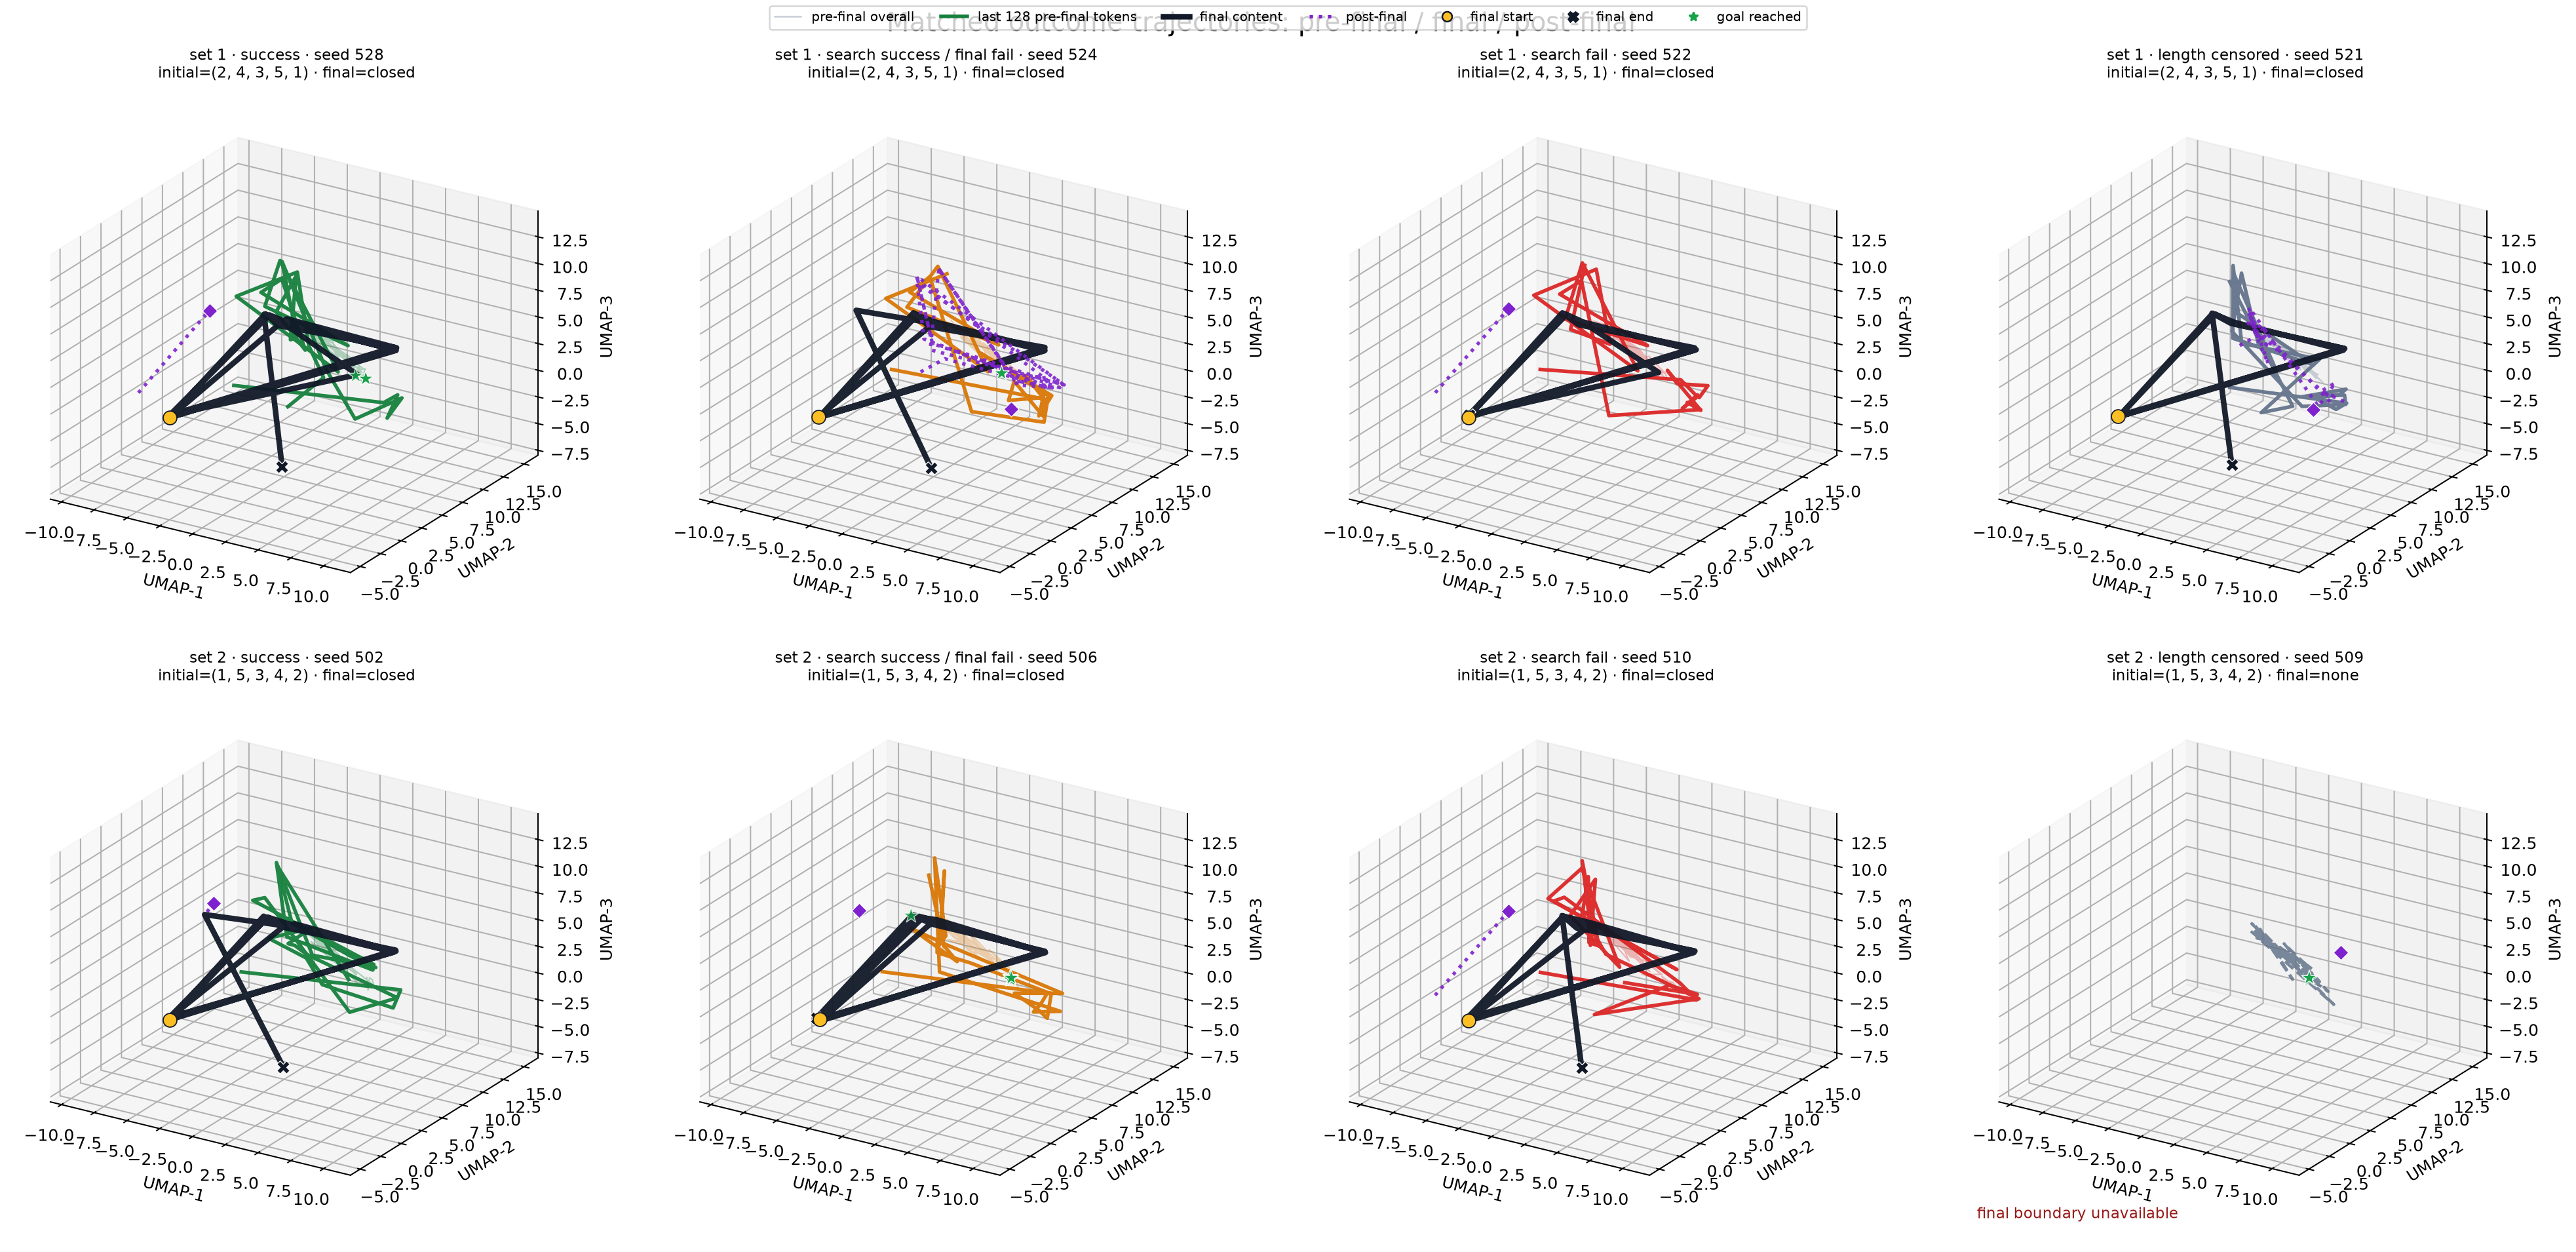

/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/figures/01_matched_pre_final_post_umap3.png


In [14]:
display_paths = {}
all_display_blocks = []

for matched_set in matched_sets:
    for outcome in OUTCOME_ORDER:
        trial = matched_set["members"][outcome]
        seed = int(trial["sample_seed"])
        coordinates = umap_paths[seed]
        bounds = final_phase_bounds(trial, len(coordinates))

        if bounds["start"] is None:
            blocks = {
                "no_final": temporal_bin_means(
                    coordinates,
                    64,
                ),
            }
        else:
            start = bounds["start"]
            end = bounds["end"]

            blocks = {
                "pre_all": temporal_bin_means(
                    coordinates[:start],
                    48,
                ),
                "pre_local": temporal_bin_means(
                    coordinates[
                        max(0, start - BOUNDARY_WINDOW):start
                    ],
                    24,
                ),
                "final": coordinates[start:end + 1],
                "post": temporal_bin_means(
                    coordinates[end + 1:],
                    24,
                ),
            }

        display_paths[seed] = {
            "bounds": bounds,
            "blocks": blocks,
        }

        all_display_blocks.extend([
            block
            for block in blocks.values()
            if len(block)
        ])

joined = np.concatenate(all_display_blocks, axis=0)
lower = joined.min(axis=0)
upper = joined.max(axis=0)
center = (lower + upper) / 2
radius = float(np.max(upper - lower) / 2 * 1.08)

figure = plt.figure(
    figsize=(22, 10.5),
    constrained_layout=True,
)

for row_index, matched_set in enumerate(matched_sets):
    for column_index, outcome in enumerate(OUTCOME_ORDER):
        trial = matched_set["members"][outcome]
        seed = int(trial["sample_seed"])
        coordinates = umap_paths[seed]
        info = display_paths[seed]
        bounds = info["bounds"]
        blocks = info["blocks"]

        ax = figure.add_subplot(
            2,
            4,
            row_index * 4 + column_index + 1,
            projection="3d",
        )
        ax.set_proj_type("ortho")

        color = OUTCOME_COLORS[outcome]

        if bounds["start"] is None:
            path = blocks["no_final"]

            ax.plot(
                path[:, 0],
                path[:, 1],
                path[:, 2],
                color="#64748B",
                linestyle="--",
                linewidth=1.8,
                alpha=0.85,
            )

            ax.text2D(
                0.03,
                0.04,
                "final boundary unavailable",
                transform=ax.transAxes,
                color="#991B1B",
                fontsize=9,
            )
        else:
            pre_all = blocks["pre_all"]
            pre_local = blocks["pre_local"]
            final = blocks["final"]
            post = blocks["post"]

            if len(pre_all):
                ax.plot(
                    pre_all[:, 0],
                    pre_all[:, 1],
                    pre_all[:, 2],
                    color=color,
                    linewidth=0.9,
                    alpha=0.30,
                )

            if len(pre_local):
                ax.plot(
                    pre_local[:, 0],
                    pre_local[:, 1],
                    pre_local[:, 2],
                    color=color,
                    linewidth=2.2,
                    alpha=0.95,
                )

            if len(final):
                ax.plot(
                    final[:, 0],
                    final[:, 1],
                    final[:, 2],
                    color="#111827",
                    linewidth=3.4,
                    alpha=0.95,
                )

                ax.scatter(
                    final[0, 0],
                    final[0, 1],
                    final[0, 2],
                    marker="o",
                    s=70,
                    color="#FBBF24",
                    edgecolor="#111827",
                    linewidth=0.7,
                    zorder=8,
                )

                ax.scatter(
                    final[-1, 0],
                    final[-1, 1],
                    final[-1, 2],
                    marker="X",
                    s=62,
                    color="#111827",
                    edgecolor="white",
                    linewidth=0.5,
                    zorder=8,
                )

            if len(post):
                ax.plot(
                    post[:, 0],
                    post[:, 1],
                    post[:, 2],
                    color="#7E22CE",
                    linestyle=":",
                    linewidth=2.1,
                    alpha=0.90,
                )

        goal_positions = sorted({
            int(move["response_position"])
            for move in trial["events"]["moves"]
            if (
                move.get("goal_reached")
                and 0 <= int(move["response_position"]) < len(coordinates)
            )
        })

        if goal_positions:
            goal_points = coordinates[goal_positions]

            ax.scatter(
                goal_points[:, 0],
                goal_points[:, 1],
                goal_points[:, 2],
                marker="*",
                s=95,
                color="#16A34A",
                edgecolor="white",
                linewidth=0.5,
                zorder=9,
            )

        ax.scatter(
            coordinates[-1, 0],
            coordinates[-1, 1],
            coordinates[-1, 2],
            marker="D",
            s=42,
            color="#7E22CE",
            edgecolor="white",
            linewidth=0.5,
            zorder=9,
        )

        set_shared_3d_limits(ax, center, radius)
        ax.view_init(elev=23, azim=-58)

        ax.set_title(
            f"set {row_index + 1} · "
            f"{OUTCOME_LABELS[outcome]} · seed {seed}\n"
            f"initial={tuple(trial['initial_state'])} · "
            f"final={bounds['status']}",
            fontsize=9,
        )

        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")
        ax.set_zlabel("UMAP-3")

legend_handles = [
    Line2D(
        [0],
        [0],
        color="#64748B",
        linewidth=1.0,
        alpha=0.35,
        label="pre-final overall",
    ),
    Line2D(
        [0],
        [0],
        color="#15803D",
        linewidth=2.2,
        label="last 128 pre-final tokens",
    ),
    Line2D(
        [0],
        [0],
        color="#111827",
        linewidth=3.4,
        label="final content",
    ),
    Line2D(
        [0],
        [0],
        color="#7E22CE",
        linestyle=":",
        linewidth=2.1,
        label="post-final",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#FBBF24",
        markeredgecolor="#111827",
        label="final start",
    ),
    Line2D(
        [0],
        [0],
        marker="X",
        linestyle="none",
        color="#111827",
        label="final end",
    ),
    Line2D(
        [0],
        [0],
        marker="*",
        linestyle="none",
        color="#16A34A",
        label="goal reached",
    ),
]

figure.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=7,
    fontsize=8,
)

figure.suptitle(
    "Matched outcome trajectories: pre-final / final / post-final",
    fontsize=16,
)

phase_figure_path = (
    FIGURE_DIR / "01_matched_pre_final_post_umap3.png"
)

figure.savefig(
    phase_figure_path,
    dpi=180,
    bbox_inches="tight",
)
plt.close(figure)

display(IPyImage(filename=str(phase_figure_path)))
print(phase_figure_path)

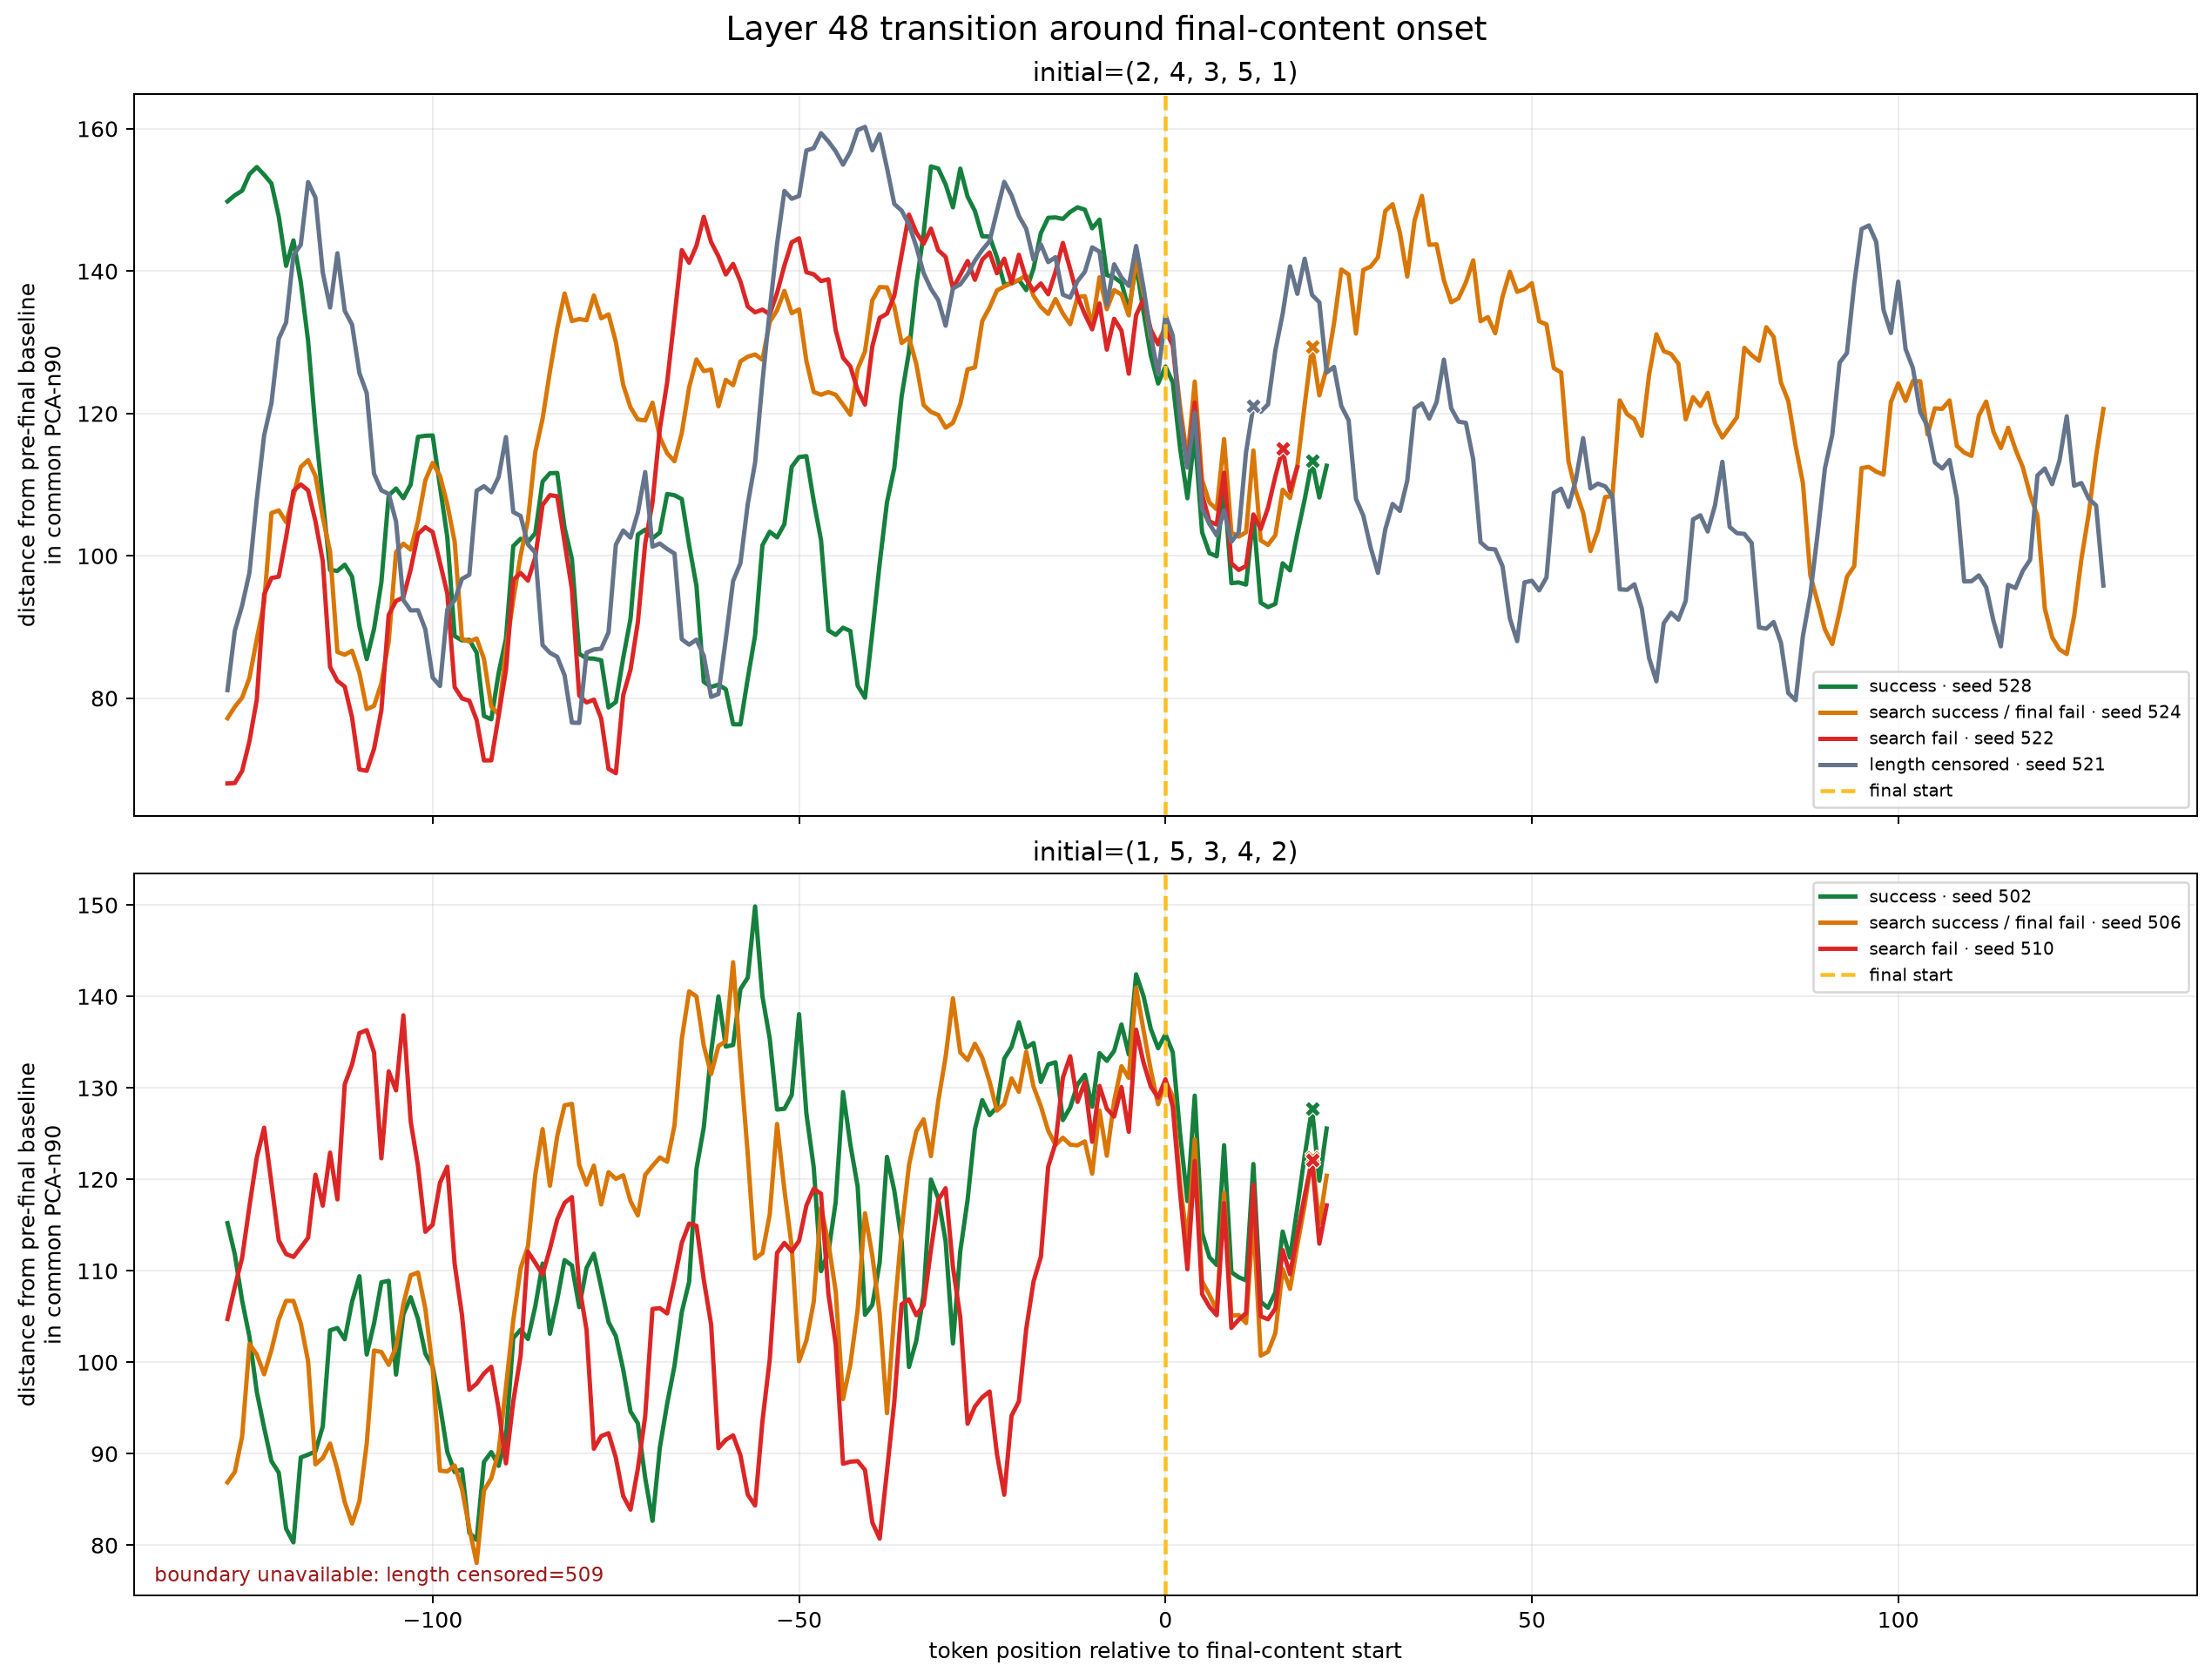

/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/figures/02_final_boundary_aligned_pca_distance.png


In [15]:
figure, axes = plt.subplots(
    len(matched_sets),
    1,
    figsize=(14, 5.3 * len(matched_sets)),
    sharex=True,
    constrained_layout=True,
)

if len(matched_sets) == 1:
    axes = [axes]

for ax, matched_set in zip(axes, matched_sets):
    unavailable = []

    for outcome in OUTCOME_ORDER:
        trial = matched_set["members"][outcome]
        seed = int(trial["sample_seed"])
        scores = pca_paths[seed]
        bounds = final_phase_bounds(trial, len(scores))

        if bounds["start"] is None:
            unavailable.append(
                f"{OUTCOME_LABELS[outcome]}={seed}"
            )
            continue

        final_start = bounds["start"]
        final_end = bounds["end"]

        low = max(0, final_start - BOUNDARY_WINDOW)
        high = min(
            len(scores),
            final_start + BOUNDARY_WINDOW + 1,
        )

        # final開始より128〜64 token前を基準状態とする。
        baseline_low = max(0, final_start - BOUNDARY_WINDOW)
        baseline_high = max(
            baseline_low + 1,
            final_start - BOUNDARY_WINDOW // 2,
        )
        baseline = scores[
            baseline_low:baseline_high
        ].mean(axis=0)

        distance = np.linalg.norm(
            scores[low:high] - baseline,
            axis=1,
        )

        smoothing_width = 9
        half_width = smoothing_width // 2
        kernel = (
            np.ones(smoothing_width)
            / smoothing_width
        )

        smoothed = np.convolve(
            np.pad(
                distance,
                (half_width, half_width),
                mode="edge",
            ),
            kernel,
            mode="valid",
        )

        relative_position = (
            np.arange(low, high) - final_start
        )

        ax.plot(
            relative_position,
            smoothed,
            color=OUTCOME_COLORS[outcome],
            linewidth=2.0,
            label=(
                f"{OUTCOME_LABELS[outcome]} "
                f"· seed {seed}"
            ),
        )

        final_end_relative = final_end - final_start

        if (
            relative_position[0]
            <= final_end_relative
            <= relative_position[-1]
        ):
            end_index = int(
                final_end_relative - relative_position[0]
            )

            ax.scatter(
                final_end_relative,
                smoothed[end_index],
                marker="X",
                s=52,
                color=OUTCOME_COLORS[outcome],
                edgecolor="white",
                linewidth=0.5,
                zorder=5,
            )

    ax.axvline(
        0,
        color="#FBBF24",
        linestyle="--",
        linewidth=1.8,
        label="final start",
    )

    if unavailable:
        ax.text(
            0.01,
            0.02,
            "boundary unavailable: " + ", ".join(unavailable),
            transform=ax.transAxes,
            fontsize=9,
            color="#991B1B",
        )

    ax.set_title(
        f"initial={tuple(matched_set['initial_state'])}"
    )
    ax.set_ylabel(
        "distance from pre-final baseline\n"
        "in common PCA-n90"
    )
    ax.grid(alpha=0.22)
    ax.legend(fontsize=8)

axes[-1].set_xlabel(
    "token position relative to final-content start"
)

figure.suptitle(
    "Layer 48 transition around final-content onset",
    fontsize=15,
)

boundary_figure_path = (
    FIGURE_DIR
    / "02_final_boundary_aligned_pca_distance.png"
)

figure.savefig(
    boundary_figure_path,
    dpi=180,
    bbox_inches="tight",
)
plt.close(figure)

display(IPyImage(filename=str(boundary_figure_path)))
print(boundary_figure_path)

In [16]:
import html
import re
import subprocess
import sys

from IPython.display import HTML

# data_access/をimportできるよう、リポジトリルートを追加する。
repo_root_string = str(REPO_ROOT)

if repo_root_string not in sys.path:
    sys.path.insert(0, repo_root_string)

from data_access.config import resolve_data_root
from data_access.loader import RcloneRemoteBackend, sha256_file
from data_access.registry import get_puzzle_spec


TEXT_ROOT = OUTPUT_ROOT / "texts"
TEXT_ROOT.mkdir(parents=True, exist_ok=True)

# data_access registryから正規のcell/remoteを解決する。
puzzle_spec = get_puzzle_spec("pancake")
cell_spec = puzzle_spec.resolve_cell({
    "N": 5,
    "mm": 5,
})

remote_cell = (
    f"{cell_spec.default_remote_root}/{cell_spec.cell_id}"
)

# 既に取得済みのlocal CELL_MANIFESTがあれば利用する。
data_root = resolve_data_root(None)
local_cell_dir = (
    data_root
    / cell_spec.dataset_id
    / cell_spec.puzzle
    / cell_spec.cell_id
)
cell_manifest_path = (
    local_cell_dir / "CELL_MANIFEST.json"
)

# manifestがなければ、小さいmetadataだけ取得する。
if not cell_manifest_path.is_file():
    metadata_dir = TEXT_ROOT / "_cell_metadata"
    backend = RcloneRemoteBackend()
    backend.download_metadata(remote_cell, metadata_dir)
    cell_manifest_path = (
        metadata_dir / "CELL_MANIFEST.json"
    )

cell_manifest = json.loads(
    cell_manifest_path.read_text(encoding="utf-8")
)

manifest_by_trial = {
    row["trial_id"]: row
    for row in cell_manifest["trials"]
}

# hidden/hidden.h5は含めない。
LIGHTWEIGHT_ARTIFACTS = [
    "checksums.json",
    "raw/generated.txt",
    "raw/prompt.txt",
    "raw/formatted_prompt.txt",
    "raw/spans_v1.json",
    "raw/metadata.json",
    "debug/replay_v1.json",
    "labels/labels_v1.json",
]

selected_trial_ids = sorted({
    trial["trial_id"]
    for matched_set in matched_sets
    for trial in matched_set["members"].values()
})

missing_patterns = []

for trial_id in selected_trial_ids:
    for relative_path in LIGHTWEIGHT_ARTIFACTS:
        destination = TEXT_ROOT / trial_id / relative_path

        if not destination.is_file():
            missing_patterns.append(
                f"/{trial_id}/{relative_path}"
            )

if missing_patterns:
    command = [
        "rclone",
        "copy",
        f"{remote_cell}/trials",
        str(TEXT_ROOT),
    ]

    for pattern in missing_patterns:
        command.extend(["--include", pattern])

    command.extend([
        "--retries",
        "3",
        "--low-level-retries",
        "10",
    ])

    completed = subprocess.run(
        command,
        cwd=REPO_ROOT,
        text=True,
        capture_output=True,
        check=False,
    )

    if completed.returncode != 0:
        detail = (
            completed.stderr
            or completed.stdout
            or "unknown rclone error"
        ).strip()
        raise RuntimeError(
            f"軽量artifact取得に失敗しました: {detail}"
        )

    print(
        f"{len(missing_patterns)} filesを取得しました"
    )
else:
    print("軽量artifactはすべて取得済みです")

# checksums.jsonを信頼の起点にして、取得物を検証する。
validation_rows = []

for trial_id in selected_trial_ids:
    trial_dir = TEXT_ROOT / trial_id
    checksums_path = trial_dir / "checksums.json"
    manifest_row = manifest_by_trial[trial_id]

    actual_checksums_sha256 = sha256_file(checksums_path)

    if actual_checksums_sha256 != manifest_row["checksums_sha256"]:
        raise AssertionError(
            f"checksums.json SHA-256不一致: {trial_id}"
        )

    checksums = json.loads(
        checksums_path.read_text(encoding="utf-8")
    )
    checksum_by_path = {
        row["path"]: row
        for row in checksums["files"]
    }

    for relative_path in LIGHTWEIGHT_ARTIFACTS:
        if relative_path == "checksums.json":
            continue

        path = trial_dir / relative_path
        expected = checksum_by_path[relative_path]

        if path.stat().st_size != int(expected["size"]):
            raise AssertionError(
                f"size不一致: {trial_id}/{relative_path}"
            )

        if sha256_file(path) != expected["sha256"]:
            raise AssertionError(
                f"SHA-256不一致: "
                f"{trial_id}/{relative_path}"
            )

    generated_path = trial_dir / "raw/generated.txt"
    spans_path = trial_dir / "raw/spans_v1.json"

    generated_sha256 = sha256_file(generated_path)
    spans = json.loads(
        spans_path.read_text(encoding="utf-8")
    )

    if generated_sha256 != manifest_row["generated_text_sha256"]:
        raise AssertionError(
            f"generated text hash不一致: {trial_id}"
        )

    if spans["generated_text_sha256"] != generated_sha256:
        raise AssertionError(
            f"spans/generated text hash不一致: {trial_id}"
        )

    if not spans.get("mapping_verified"):
        raise AssertionError(
            f"token span mapping未検証: {trial_id}"
        )

    validation_rows.append({
        "trial_id": trial_id,
        "generated_text_sha256": generated_sha256,
        "mapping_verified": True,
    })

validation_path = (
    TABLE_DIR / "text_artifact_validation.json"
)
validation_path.write_text(
    json.dumps(
        validation_rows,
        ensure_ascii=False,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)

print(f"検証完了: {len(validation_rows)} trials")
print(f"保存先: {TEXT_ROOT}")

軽量artifactはすべて取得済みです
検証完了: 8 trials
保存先: /home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts


In [17]:
def extract_final_blocks(
    generated_text: str,
    spans_payload: dict,
) -> list[dict]:
    """final tagのchar spanから各final blockを抽出する。"""
    final_tags = sorted(
        [
            span
            for span in spans_payload["spans"]
            if span.get("kind") == "final_tag"
        ],
        key=lambda span: tuple(span["char_span"]),
    )

    blocks = []
    open_tag = None

    for tag in final_tags:
        if tag["text"] == "<final>":
            open_tag = tag
            continue

        if tag["text"] == "</final>" and open_tag is not None:
            open_start, open_end = map(
                int,
                open_tag["char_span"],
            )
            close_start, close_end = map(
                int,
                tag["char_span"],
            )

            blocks.append({
                "status": "closed",
                "open_tag_start": open_start,
                "content_start": open_end,
                "content_end": close_start,
                "close_tag_end": close_end,
                "content": generated_text[
                    open_end:close_start
                ],
                "with_tags": generated_text[
                    open_start:close_end
                ],
            })
            open_tag = None

    if open_tag is not None:
        open_start, open_end = map(
            int,
            open_tag["char_span"],
        )

        blocks.append({
            "status": "open",
            "open_tag_start": open_start,
            "content_start": open_end,
            "content_end": len(generated_text),
            "close_tag_end": len(generated_text),
            "content": generated_text[open_end:],
            "with_tags": generated_text[open_start:],
        })

    return blocks


def show_text_block(
    title: str,
    text: str,
    *,
    opened: bool = False,
) -> None:
    """長いテキストを折り畳み可能なHTMLとして表示する。"""
    open_attribute = " open" if opened else ""

    display(HTML(
        f"<details{open_attribute}>"
        f"<summary><strong>{html.escape(title)}</strong></summary>"
        f"<pre style='white-space: pre-wrap; "
        f"overflow-wrap: anywhere; "
        f"border: 1px solid #d1d5db; "
        f"padding: 12px;'>"
        f"{html.escape(text)}"
        f"</pre>"
        f"</details>"
    ))


inspection_records = []

for set_index, matched_set in enumerate(matched_sets, start=1):
    for outcome in OUTCOME_ORDER:
        trial = matched_set["members"][outcome]
        seed = int(trial["sample_seed"])
        trial_id = trial["trial_id"]
        trial_dir = TEXT_ROOT / trial_id

        generated_text = (
            trial_dir / "raw/generated.txt"
        ).read_text(encoding="utf-8")

        prompt_text = (
            trial_dir / "raw/prompt.txt"
        ).read_text(encoding="utf-8")

        spans_payload = json.loads(
            (
                trial_dir / "raw/spans_v1.json"
            ).read_text(encoding="utf-8")
        )

        labels_payload = json.loads(
            (
                trial_dir / "labels/labels_v1.json"
            ).read_text(encoding="utf-8")
        )

        final_blocks = extract_final_blocks(
            generated_text,
            spans_payload,
        )

        if final_blocks:
            last_final = final_blocks[-1]
            pre_final = generated_text[
                :last_final["open_tag_start"]
            ]
            final_content = last_final["content"]
            post_final = generated_text[
                last_final["close_tag_end"]:
            ]
            final_status = last_final["status"]
        else:
            last_final = None
            pre_final = generated_text
            final_content = ""
            post_final = ""
            final_status = "none"

        final_flip_sequence = [
            int(value)
            for value in re.findall(
                r"\bFlip\s+(\d+)\b",
                final_content,
                flags=re.IGNORECASE,
            )
        ]

        record = {
            "matched_set": set_index,
            "initial_state": list(
                matched_set["initial_state"]
            ),
            "outcome": outcome,
            "sample_seed": seed,
            "trial_id": trial_id,
            "final_status": final_status,
            "final_block_count": len(final_blocks),
            "generated_character_count": len(generated_text),
            "pre_final_character_count": len(pre_final),
            "final_character_count": len(final_content),
            "post_final_character_count": len(post_final),
            "final_flip_sequence": final_flip_sequence,
            "final_content": final_content,
            "label_outcome": labels_payload["outcome"],
        }
        inspection_records.append(record)

        display(Markdown(
            f"### set {set_index} · "
            f"{OUTCOME_LABELS[outcome]} · seed {seed}\n\n"
            f"- trial: `{trial_id}`\n"
            f"- final status: `{final_status}`\n"
            f"- final blocks: `{len(final_blocks)}`\n"
            f"- final Flip sequence: `{final_flip_sequence}`\n"
            f"- generated text: `{trial_dir / 'raw/generated.txt'}`"
        ))

        show_text_block(
            "入力prompt",
            prompt_text,
            opened=False,
        )

        if final_blocks:
            show_text_block(
                "last final直前の末尾2000文字",
                pre_final[-2000:],
                opened=False,
            )

            for block_index, block in enumerate(
                final_blocks,
                start=1,
            ):
                show_text_block(
                    f"final block {block_index} "
                    f"({block['status']})",
                    block["with_tags"],
                    opened=True,
                )

            if post_final:
                show_text_block(
                    "last final終了後の先頭2000文字",
                    post_final[:2000],
                    opened=True,
                )
        else:
            show_text_block(
                "finalなし：generated text末尾3000文字",
                generated_text[-3000:],
                opened=True,
            )

### set 1 · success · seed 528

- trial: `N5_mm5_state03_trial008_seed528`
- final status: `closed`
- final blocks: `1`
- final Flip sequence: `[5, 4, 5, 2, 4]`
- generated text: `/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/N5_mm5_state03_trial008_seed528/raw/generated.txt`

### set 1 · search success / final fail · seed 524

- trial: `N5_mm5_state03_trial004_seed524`
- final status: `closed`
- final blocks: `1`
- final Flip sequence: `[5, 2, 5, 3, 5]`
- generated text: `/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/N5_mm5_state03_trial004_seed524/raw/generated.txt`

### set 1 · search fail · seed 522

- trial: `N5_mm5_state03_trial002_seed522`
- final status: `closed`
- final blocks: `1`
- final Flip sequence: `[5, 4, 3, 5]`
- generated text: `/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/N5_mm5_state03_trial002_seed522/raw/generated.txt`

### set 1 · length censored · seed 521

- trial: `N5_mm5_state03_trial001_seed521`
- final status: `closed`
- final blocks: `1`
- final Flip sequence: `[5, 4, 2]`
- generated text: `/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/N5_mm5_state03_trial001_seed521/raw/generated.txt`

### set 2 · success · seed 502

- trial: `N5_mm5_state01_trial002_seed502`
- final status: `closed`
- final blocks: `1`
- final Flip sequence: `[4, 5, 3, 5, 4]`
- generated text: `/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/N5_mm5_state01_trial002_seed502/raw/generated.txt`

### set 2 · search success / final fail · seed 506

- trial: `N5_mm5_state01_trial006_seed506`
- final status: `closed`
- final blocks: `2`
- final Flip sequence: `[3, 5, 2, 4, 3]`
- generated text: `/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/N5_mm5_state01_trial006_seed506/raw/generated.txt`

### set 2 · search fail · seed 510

- trial: `N5_mm5_state01_trial010_seed510`
- final status: `closed`
- final blocks: `1`
- final Flip sequence: `[5, 4, 5, 4, 4]`
- generated text: `/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/N5_mm5_state01_trial010_seed510/raw/generated.txt`

### set 2 · length censored · seed 509

- trial: `N5_mm5_state01_trial009_seed509`
- final status: `none`
- final blocks: `0`
- final Flip sequence: `[]`
- generated text: `/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/N5_mm5_state01_trial009_seed509/raw/generated.txt`

In [18]:
comparison_table_path = (
    TABLE_DIR / "generated_final_text_comparison.csv"
)

comparison_table_rows = [
    {
        key: (
            json.dumps(value, ensure_ascii=False)
            if isinstance(value, list)
            else value
        )
        for key, value in record.items()
        if key != "final_content"
    }
    | {
        "final_content": record["final_content"],
    }
    for record in inspection_records
]

with comparison_table_path.open(
    "w",
    encoding="utf-8",
    newline="",
) as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=list(comparison_table_rows[0]),
    )
    writer.writeheader()
    writer.writerows(comparison_table_rows)

display(Markdown(markdown_table(
    [
        "set",
        "outcome",
        "seed",
        "status",
        "final blocks",
        "final chars",
        "post chars",
        "final Flip sequence",
    ],
    [
        [
            str(record["matched_set"]),
            record["outcome"],
            str(record["sample_seed"]),
            record["final_status"],
            str(record["final_block_count"]),
            str(record["final_character_count"]),
            str(record["post_final_character_count"]),
            str(record["final_flip_sequence"]),
        ]
        for record in inspection_records
    ],
)))

# final部分だけを個別textとしても保存する。
extracted_final_dir = TEXT_ROOT / "extracted_final"
extracted_final_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for record in inspection_records:
    seed = record["sample_seed"]
    outcome = record["outcome"]

    output_path = (
        extracted_final_dir
        / f"seed_{seed}_{outcome}.txt"
    )

    output_path.write_text(
        record["final_content"],
        encoding="utf-8",
    )

print(comparison_table_path)
print(extracted_final_dir)

| set | outcome | seed | status | final blocks | final chars | post chars | final Flip sequence |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | success_final | 528 | closed | 1 | 36 | 0 | [5, 4, 5, 2, 4] |
| 1 | search_success_final_fail | 524 | closed | 1 | 44 | 636 | [5, 2, 5, 3, 5] |
| 1 | search_fail | 522 | closed | 1 | 29 | 0 | [5, 4, 3, 5] |
| 1 | length_censored | 521 | closed | 1 | 22 | 1554 | [5, 4, 2] |
| 2 | success_final | 502 | closed | 1 | 36 | 0 | [4, 5, 3, 5, 4] |
| 2 | search_success_final_fail | 506 | closed | 2 | 36 | 0 | [3, 5, 2, 4, 3] |
| 2 | search_fail | 510 | closed | 1 | 46 | 0 | [5, 4, 5, 4, 4] |
| 2 | length_censored | 509 | none | 0 | 0 | 0 | [] |

/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/tables/generated_final_text_comparison.csv
/home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/texts/extracted_final


## Manual phase annotation and token-hidden synchronization

In [19]:
import csv
import hashlib
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
from IPython.display import Markdown, display

# cell 16と21で選定・取得・信頼検証した8 trialを入力にする。
required_names = [
    "REPO_ROOT",
    "OUTPUT_ROOT",
    "TABLE_DIR",
    "TEXT_ROOT",
    "selected_trial_ids",
    "remote_cell",
    "sha256_file",
]
missing_names = [
    name for name in required_names
    if name not in globals()
]
if missing_names:
    raise RuntimeError(
        "先にcell 16と21を実行してください: "
        f"missing={missing_names}"
    )

from transformers import AutoTokenizer

PHASE_ROOT = OUTPUT_ROOT / "phase_annotations"
PHASE_REVIEW_DIR = PHASE_ROOT / "review_text"
PHASE_DERIVED_DIR = PHASE_ROOT / "derived"
PHASE_MANUAL_PATH = (
    PHASE_ROOT / "phase_boundaries_manual_v1.csv"
)
PHASE_CODEBOOK_PATH = (
    PHASE_ROOT / "phase_label_codebook_v1.json"
)
PHASE_INPUT_VALIDATION_PATH = (
    TABLE_DIR / "phase_input_validation_v1.csv"
)
TOKEN_RELATIVE_PATH = "raw/generated_token_ids.npy"

with (TABLE_DIR / "matched_seed_selection.csv").open(
    encoding="utf-8",
    newline="",
) as handle:
    phase_selection_by_seed = {
        int(row["sample_seed"]): row
        for row in csv.DictReader(handle)
    }

if len(selected_trial_ids) != 8:
    raise AssertionError("selected trialsは8件です")

for directory in [
    PHASE_ROOT,
    PHASE_REVIEW_DIR,
    PHASE_DERIVED_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

PHASE_CODEBOOK = {
    "setup": "問題、操作、初期状態、目標を確認する。",
    "plan": "複数手にわたる戦略、algorithm、subgoalの順序を決める。",
    "state_simulation": "Flip後の具体的な状態を計算・追跡する。",
    "move_proposal": "現在地点から具体的なFlip候補を提案する局所探索。",
    "verification": "状態、正しさ、進捗、手数を検査する。",
    "backtracking": "現在の試行を捨て、以前の地点や別方針へ戻る。",
    "self_correction": "直前の局所的な計算・記述ミスを訂正する。",
    "loop_like": "既出の試行・状態・議論を進展なく反復する。",
    "final_commit": "<final>から</final>までの提出部分。",
}
PHASE_PRECEDENCE = [
    "final_commit",
    "self_correction",
    "backtracking",
    "loop_like",
    "verification",
    "state_simulation",
    "move_proposal",
    "plan",
    "setup",
]
PHASE_CODEBOOK_PATH.write_text(
    json.dumps(
        {
            "schema_version": 1,
            "span_convention": "half-open [start, end)",
            "primary_label_exclusive": True,
            "full_text_partition_required": True,
            "precedence": PHASE_PRECEDENCE,
            "labels": PHASE_CODEBOOK,
        },
        ensure_ascii=False,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

missing_patterns = []
for trial_id in selected_trial_ids:
    token_path = TEXT_ROOT / trial_id / TOKEN_RELATIVE_PATH
    if not token_path.is_file():
        missing_patterns.append(
            f"/{trial_id}/{TOKEN_RELATIVE_PATH}"
        )

if missing_patterns:
    command = [
        "rclone",
        "copy",
        f"{remote_cell}/trials",
        str(TEXT_ROOT),
    ]
    for pattern in missing_patterns:
        command.extend(["--include", pattern])
    command.extend([
        "--retries",
        "3",
        "--low-level-retries",
        "10",
    ])
    completed = subprocess.run(
        command,
        cwd=REPO_ROOT,
        text=True,
        capture_output=True,
        check=False,
    )
    if completed.returncode != 0:
        detail = (
            completed.stderr
            or completed.stdout
            or "unknown rclone error"
        ).strip()
        raise RuntimeError(
            f"token ID取得に失敗しました: {detail}"
        )
    print(f"{len(missing_patterns)} filesを取得")
else:
    print("token ID filesは取得済みです")

phase_records = {}
tokenizer_names = set()
model_revisions = set()

for trial_id in selected_trial_ids:
    trial_dir = TEXT_ROOT / trial_id
    checksums = json.loads(
        (trial_dir / "checksums.json").read_text(
            encoding="utf-8"
        )
    )
    checksum_by_path = {
        row["path"]: row
        for row in checksums["files"]
    }
    token_path = trial_dir / TOKEN_RELATIVE_PATH
    expected = checksum_by_path[TOKEN_RELATIVE_PATH]
    if token_path.stat().st_size != int(expected["size"]):
        raise AssertionError(
            f"token ID size不一致: {trial_id}"
        )
    if sha256_file(token_path) != expected["sha256"]:
        raise AssertionError(
            f"token ID SHA-256不一致: {trial_id}"
        )

    text = (trial_dir / "raw/generated.txt").read_text(
        encoding="utf-8"
    )
    token_ids = np.load(
        token_path,
        allow_pickle=False,
    ).astype(np.int64)
    metadata = json.loads(
        (trial_dir / "raw/metadata.json").read_text(
            encoding="utf-8"
        )
    )
    spans = json.loads(
        (trial_dir / "raw/spans_v1.json").read_text(
            encoding="utf-8"
        )
    )
    if len(token_ids) != int(
        metadata["generated_token_count"]
    ):
        raise AssertionError(
            f"metadata/token count不一致: {trial_id}"
        )
    if hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest() != spans["generated_text_sha256"]:
        raise AssertionError(
            f"generated/spans hash不一致: {trial_id}"
        )

    phase_records[trial_id] = {
        "trial_dir": trial_dir,
        "text": text,
        "token_ids": token_ids,
        "metadata": metadata,
        "spans": spans,
        "matched_set": int(
            phase_selection_by_seed[
                int(metadata["sample_seed"])
            ]["matched_set"]
        ),
        "outcome": phase_selection_by_seed[
            int(metadata["sample_seed"])
        ]["outcome"],
    }
    tokenizer_names.add(metadata["tokenizer_name"])
    model_revisions.add(metadata["model_revision"])

if len(tokenizer_names) != 1 or len(model_revisions) != 1:
    raise AssertionError(
        "8 trialのtokenizer/revisionが一致しません"
    )

phase_tokenizer = AutoTokenizer.from_pretrained(
    next(iter(tokenizer_names)),
    revision=next(iter(model_revisions)),
    trust_remote_code=True,
    use_fast=True,
)
if not phase_tokenizer.is_fast:
    raise AssertionError("fast tokenizerが必要です")

validation_rows = []


def paragraph_ranges(text: str) -> list[tuple[int, int]]:
    """空行で区切った閲覧用段落のchar範囲を返す。"""
    starts = [0]
    offset = 0
    previous_blank = False
    for line in text.splitlines(keepends=True):
        blank = not line.strip()
        if previous_blank and not blank:
            starts.append(offset)
        previous_blank = blank
        offset += len(line)
    starts = sorted(set(starts))
    return [
        (
            start,
            starts[index + 1]
            if index + 1 < len(starts)
            else len(text),
        )
        for index, start in enumerate(starts)
    ]


for trial_id, record in phase_records.items():
    encoded = phase_tokenizer(
        record["text"],
        add_special_tokens=False,
        return_offsets_mapping=True,
    )
    retokenized_ids = np.asarray(
        encoded["input_ids"],
        dtype=np.int64,
    )
    if not np.array_equal(
        retokenized_ids,
        record["token_ids"],
    ):
        raise AssertionError(
            f"retokenized/saved IDs不一致: {trial_id}"
        )
    record["offsets"] = np.asarray(
        encoded["offset_mapping"],
        dtype=np.int64,
    )

    tag_lines = [
        (
            f"- {span['text']!r}: "
            f"{span['char_span']}"
        )
        for span in record["spans"]["spans"]
        if span.get("kind") == "final_tag"
    ]
    review_lines = [
        "# Manual phase annotation review text",
        "",
        f"trial_id: {trial_id}",
        f"generated_characters: {len(record['text'])}",
        f"generated_tokens: {len(record['token_ids'])}",
        "labels: " + ", ".join(PHASE_CODEBOOK),
        "",
        "final tag candidates:",
        *(tag_lines or ["- none"]),
    ]
    for index, (
        char_start,
        char_end,
    ) in enumerate(
        paragraph_ranges(record["text"]),
        start=1,
    ):
        review_lines.extend([
            "",
            (
                f"===== paragraph {index:04d} | "
                f"char_start={char_start} | "
                f"char_end={char_end} ====="
            ),
            record["text"][
                char_start:char_end
            ].rstrip("\n"),
        ])
    (
        PHASE_REVIEW_DIR / f"{trial_id}.txt"
    ).write_text(
        "\n".join(review_lines) + "\n",
        encoding="utf-8",
    )
    validation_rows.append({
        "trial_id": trial_id,
        "generated_characters": len(record["text"]),
        "generated_tokens": len(record["token_ids"]),
        "retokenize_exact_match": True,
    })

with PHASE_INPUT_VALIDATION_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=list(validation_rows[0]),
    )
    writer.writeheader()
    writer.writerows(validation_rows)

manual_columns = [
    "trial_id",
    "segment_index",
    "phase",
    "char_start",
    "evidence_note",
]
if not PHASE_MANUAL_PATH.exists():
    with PHASE_MANUAL_PATH.open(
        "w",
        encoding="utf-8",
        newline="",
    ) as handle:
        writer = csv.DictWriter(
            handle,
            fieldnames=manual_columns,
        )
        writer.writeheader()
        for trial_id in selected_trial_ids:
            writer.writerow({
                "trial_id": trial_id,
                "segment_index": 0,
                "phase": "",
                "char_start": 0,
                "evidence_note": "generated completion start",
            })
    manual_status = "新規作成"
else:
    manual_status = "既存fileを保持"

display(Markdown(
    "### Phase annotation input ready\n\n"
    f"- exact retokenization: **{len(validation_rows)}/8**\n"
    f"- manual CSV: {PHASE_MANUAL_PATH} ({manual_status})\n"
    f"- review texts: {PHASE_REVIEW_DIR}\n"
    "- hidden.h5: **not downloaded**"
))

/home/shona/Modeling_of_LLMs_LPT/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


8 filesを取得


### Phase annotation input ready

- exact retokenization: **8/8**
- manual CSV: /home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/phase_annotations/phase_boundaries_manual_v1.csv (新規作成)
- review texts: /home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/phase_annotations/review_text
- hidden.h5: **not downloaded**

In [22]:
if "phase_records" not in globals():
    raise RuntimeError(
        "直前のphase input cellを先に実行してください"
    )

from runners.pancake_dataset_artifacts import (
    map_char_spans_to_tokens,
)

SYNC_PATH = (
    TABLE_DIR / "phase_char_token_hidden_sync_v1.csv"
)
CHECKPOINT_PATH = (
    TABLE_DIR / "candidate_checkpoints_v1.csv"
)
COORDINATE_PATH = (
    OUTPUT_ROOT
    / "coordinates/N5_mm5_matched_common_pca_umap.npz"
)

with PHASE_MANUAL_PATH.open(
    encoding="utf-8",
    newline="",
) as handle:
    manual_rows = list(csv.DictReader(handle))

raw_rows_by_trial = {
    trial_id: [] for trial_id in selected_trial_ids
}
for row_number, row in enumerate(manual_rows, start=2):
    trial_id = row["trial_id"].strip()
    if trial_id not in raw_rows_by_trial:
        raise ValueError(
            f"row {row_number}: 未知のtrial_id={trial_id!r}"
        )
    raw_rows_by_trial[trial_id].append((row_number, row))

manual_by_trial = {
    trial_id: [] for trial_id in selected_trial_ids
}
pending_trial_ids = []
for trial_id, numbered_rows in raw_rows_by_trial.items():
    is_pending_placeholder = (
        len(numbered_rows) == 1
        and numbered_rows[0][1]["segment_index"].strip() == "0"
        and not numbered_rows[0][1]["phase"].strip()
        and numbered_rows[0][1]["char_start"].strip() == "0"
    )
    if not numbered_rows or is_pending_placeholder:
        pending_trial_ids.append(trial_id)
        continue

    for row_number, row in numbered_rows:
        phase = row["phase"].strip()
        if not phase:
            raise ValueError(
                f"row {row_number}: annotation途中の"
                "phaseが未入力です"
            )
        if phase not in PHASE_CODEBOOK:
            raise ValueError(
                f"row {row_number}: 未知のphase={phase!r}"
            )
        manual_by_trial[trial_id].append({
            "segment_index": int(row["segment_index"]),
            "phase": phase,
            "char_start": int(row["char_start"]),
            "evidence_note": row.get(
                "evidence_note", ""
            ).strip(),
        })

annotated_trial_ids = [
    trial_id for trial_id in selected_trial_ids
    if manual_by_trial[trial_id]
]
if not annotated_trial_ids:
    raise ValueError(
        "完了したannotationがまだありません"
    )

hidden_counts = {}
with np.load(COORDINATE_PATH) as coordinate_data:
    for trial_id in annotated_trial_ids:
        seed = int(
            phase_records[trial_id]["metadata"]["sample_seed"]
        )
        hidden_counts[trial_id] = int(
            coordinate_data[f"pca_seed_{seed}"].shape[0]
        )

sync_rows = []
derived_payloads = {}

for trial_id in annotated_trial_ids:
    record = phase_records[trial_id]
    rows = sorted(
        manual_by_trial[trial_id],
        key=lambda item: item["segment_index"],
    )
    if [
        row["segment_index"] for row in rows
    ] != list(range(len(rows))):
        raise ValueError(
            f"segment_indexが非連続です: {trial_id}"
        )

    text = record["text"]
    token_ids = record["token_ids"]
    if hidden_counts[trial_id] != len(token_ids):
        raise AssertionError(
            f"hidden/token count不一致: {trial_id}"
        )

    starts = [row["char_start"] for row in rows]
    if starts[0] != 0:
        raise ValueError(
            f"最初のchar_startは0です: {trial_id}"
        )
    if any(
        left >= right
        for left, right in zip(starts, starts[1:])
    ):
        raise ValueError(
            f"char_startが単調増加ではありません: {trial_id}"
        )

    boundaries = [*starts, len(text)]
    spans = [
        {
            "kind": "manual_phase",
            "segment_index": index,
            "phase": row["phase"],
            "char_span": [
                boundaries[index],
                boundaries[index + 1],
            ],
            "evidence_note": row["evidence_note"],
        }
        for index, row in enumerate(rows)
    ]
    mapped = map_char_spans_to_tokens(
        text,
        token_ids.tolist(),
        phase_tokenizer,
        spans,
    )
    if not mapped.get("mapping_verified"):
        raise AssertionError(
            f"span mapping未検証: {trial_id}: "
            f"{mapped.get('reason', '')}"
        )
    mapped_spans = mapped["spans"]

    for left, right in zip(
        mapped_spans,
        mapped_spans[1:],
    ):
        if (
            left["token_span"][1]
            != right["token_span"][0]
        ):
            raise ValueError(
                "phase境界がtoken内部にあります: "
                f"{trial_id}, char={right['char_span'][0]}"
            )
    if (
        mapped_spans[0]["token_span"][0] != 0
        or mapped_spans[-1]["token_span"][1]
        != len(token_ids)
    ):
        raise ValueError(
            f"token列を完全分割していません: {trial_id}"
        )

    trial_segments = []
    for span in mapped_spans:
        char_start, char_end = span["char_span"]
        token_start, token_end = span["token_span"]
        after_available = token_end < len(token_ids)
        segment_text = text[char_start:char_end]
        sync_row = {
            "trial_id": trial_id,
            "matched_set": record["matched_set"],
            "outcome": record["outcome"],
            "sample_seed": int(
                record["metadata"]["sample_seed"]
            ),
            "segment_index": span["segment_index"],
            "phase": span["phase"],
            "char_start": char_start,
            "char_end": char_end,
            "token_start": token_start,
            "token_end": token_end,
            "token_count": token_end - token_start,
            "start_hidden_row": token_start,
            "after_hidden_row": (
                token_end if after_available else ""
            ),
            "after_hidden_available": after_available,
            "evidence_note": span["evidence_note"],
            "text_preview": (
                " ".join(segment_text.split())[:160]
            ),
        }
        sync_rows.append(sync_row)
        trial_segments.append({
            **sync_row,
            "after_hidden_row": (
                token_end if after_available else None
            ),
            "text": segment_text,
        })

    payload = {
        "schema_version": 1,
        "trial_id": trial_id,
        "generated_text_sha256": hashlib.sha256(
            text.encode("utf-8")
        ).hexdigest(),
        "generated_token_count": len(token_ids),
        "hidden_layer": 48,
        "hidden_alignment": (
            "row_t_is_context_state_used_to_sample_token_id_t"
        ),
        "span_convention": "half-open [start, end)",
        "segments": trial_segments,
    }
    derived_payloads[trial_id] = payload
    (
        PHASE_DERIVED_DIR
        / f"{trial_id}_phase_annotations_v1.json"
    ).write_text(
        json.dumps(
            payload,
            ensure_ascii=False,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )

with SYNC_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=list(sync_rows[0]),
    )
    writer.writeheader()
    writer.writerows(sync_rows)

checkpoint_rows = []
for trial_id, payload in derived_payloads.items():
    segments = payload["segments"]
    candidates = [
        (
            "phase_end",
            segment,
            "end",
        )
        for segment in segments
    ]
    for phase, kind, boundary in [
        ("plan", "first_plan_end", "end"),
        (
            "backtracking",
            "first_backtracking_end",
            "end",
        ),
        ("loop_like", "loop_onset", "start"),
    ]:
        segment = next(
            (
                item for item in segments
                if item["phase"] == phase
            ),
            None,
        )
        if segment is not None:
            candidates.append((kind, segment, boundary))

    for kind, segment, boundary in candidates:
        suffix = "end" if boundary == "end" else "start"
        token_index = segment[f"token_{suffix}"]
        available = (
            token_index
            < len(phase_records[trial_id]["token_ids"])
        )
        checkpoint_rows.append({
            "trial_id": trial_id,
            "matched_set": phase_records[trial_id][
                "matched_set"
            ],
            "outcome": phase_records[trial_id][
                "outcome"
            ],
            "sample_seed": payload["segments"][0][
                "sample_seed"
            ],
            "checkpoint_kind": kind,
            "segment_index": segment["segment_index"],
            "phase": segment["phase"],
            "boundary": boundary,
            "char_index": segment[f"char_{suffix}"],
            "token_index": token_index,
            "hidden_row": (
                token_index if available else ""
            ),
            "hidden_available": available,
            "evidence_note": segment["evidence_note"],
        })

with CHECKPOINT_PATH.open(
    "w",
    encoding="utf-8",
    newline="",
) as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=list(checkpoint_rows[0]),
    )
    writer.writeheader()
    writer.writerows(checkpoint_rows)

display(Markdown(
    "### Phase synchronization complete\n\n"
    f"- trials: **{len(derived_payloads)}**\n"
    f"- pending trials: **{len(pending_trial_ids)}**\n"
    f"- segments: **{len(sync_rows)}**\n"
    f"- checkpoints: **{len(checkpoint_rows)}**\n"
    f"- sync table: {SYNC_PATH}\n"
    f"- checkpoint table: {CHECKPOINT_PATH}"
))

### Phase synchronization complete

- trials: **1**
- pending trials: **7**
- segments: **94**
- checkpoints: **97**
- sync table: /home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/tables/phase_char_token_hidden_sync_v1.csv
- checkpoint table: /home/shona/Modeling_of_LLMs_LPT/results/pancake_2026-08-29/matched_outcome_pre_final_post/tables/candidate_checkpoints_v1.csv